# Combined Model Chromatin Deconvolution

In [1]:
# Preamble, notebook setup and imports

%load_ext autoreload
%autoreload 2
%matplotlib inline
%config InlineBackend.figure_format = 'retina'
%config Completer.use_jedi = False

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [3]:
from src.chromatin_model import ChromatinModel
from src.config import load_default_chrom_configs

config1, config2 = load_default_chrom_configs()


In [4]:
from src.combined_chromatin_model import CombinedChromatinModel
combined_model = CombinedChromatinModel(config1=config1, config2=config2)

In [28]:

chrom = 12
#mnase_span = (290212-2000, 290212+500)
mnase_span = 290212-500, 290212+500
combined_model.load_mnase_span(chrom, mnase_span)


Already loaded chromosome reads for 12. Using cache.
Loading target length distribution:  datasets/computed_mnase/target_length_distribution.csv
Loading G data from combined replication run, 3/10/25
Refactor to use the output directory, of the replication deconvolution run
Normalizing to mean 1, to target length distribution, to target 10kb occupancy sums.
And downsampling from (16, 251, 999) to (16, 26, 100)
Already loaded chromosome reads for 12. Using cache.
Loading target length distribution:  datasets/computed_mnase/target_length_distribution.csv
Loading G data from combined replication run, 3/10/25
Refactor to use the output directory, of the replication deconvolution run
Normalizing to mean 1, to target length distribution, to target 10kb occupancy sums.
And downsampling from (15, 251, 999) to (15, 26, 100)


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


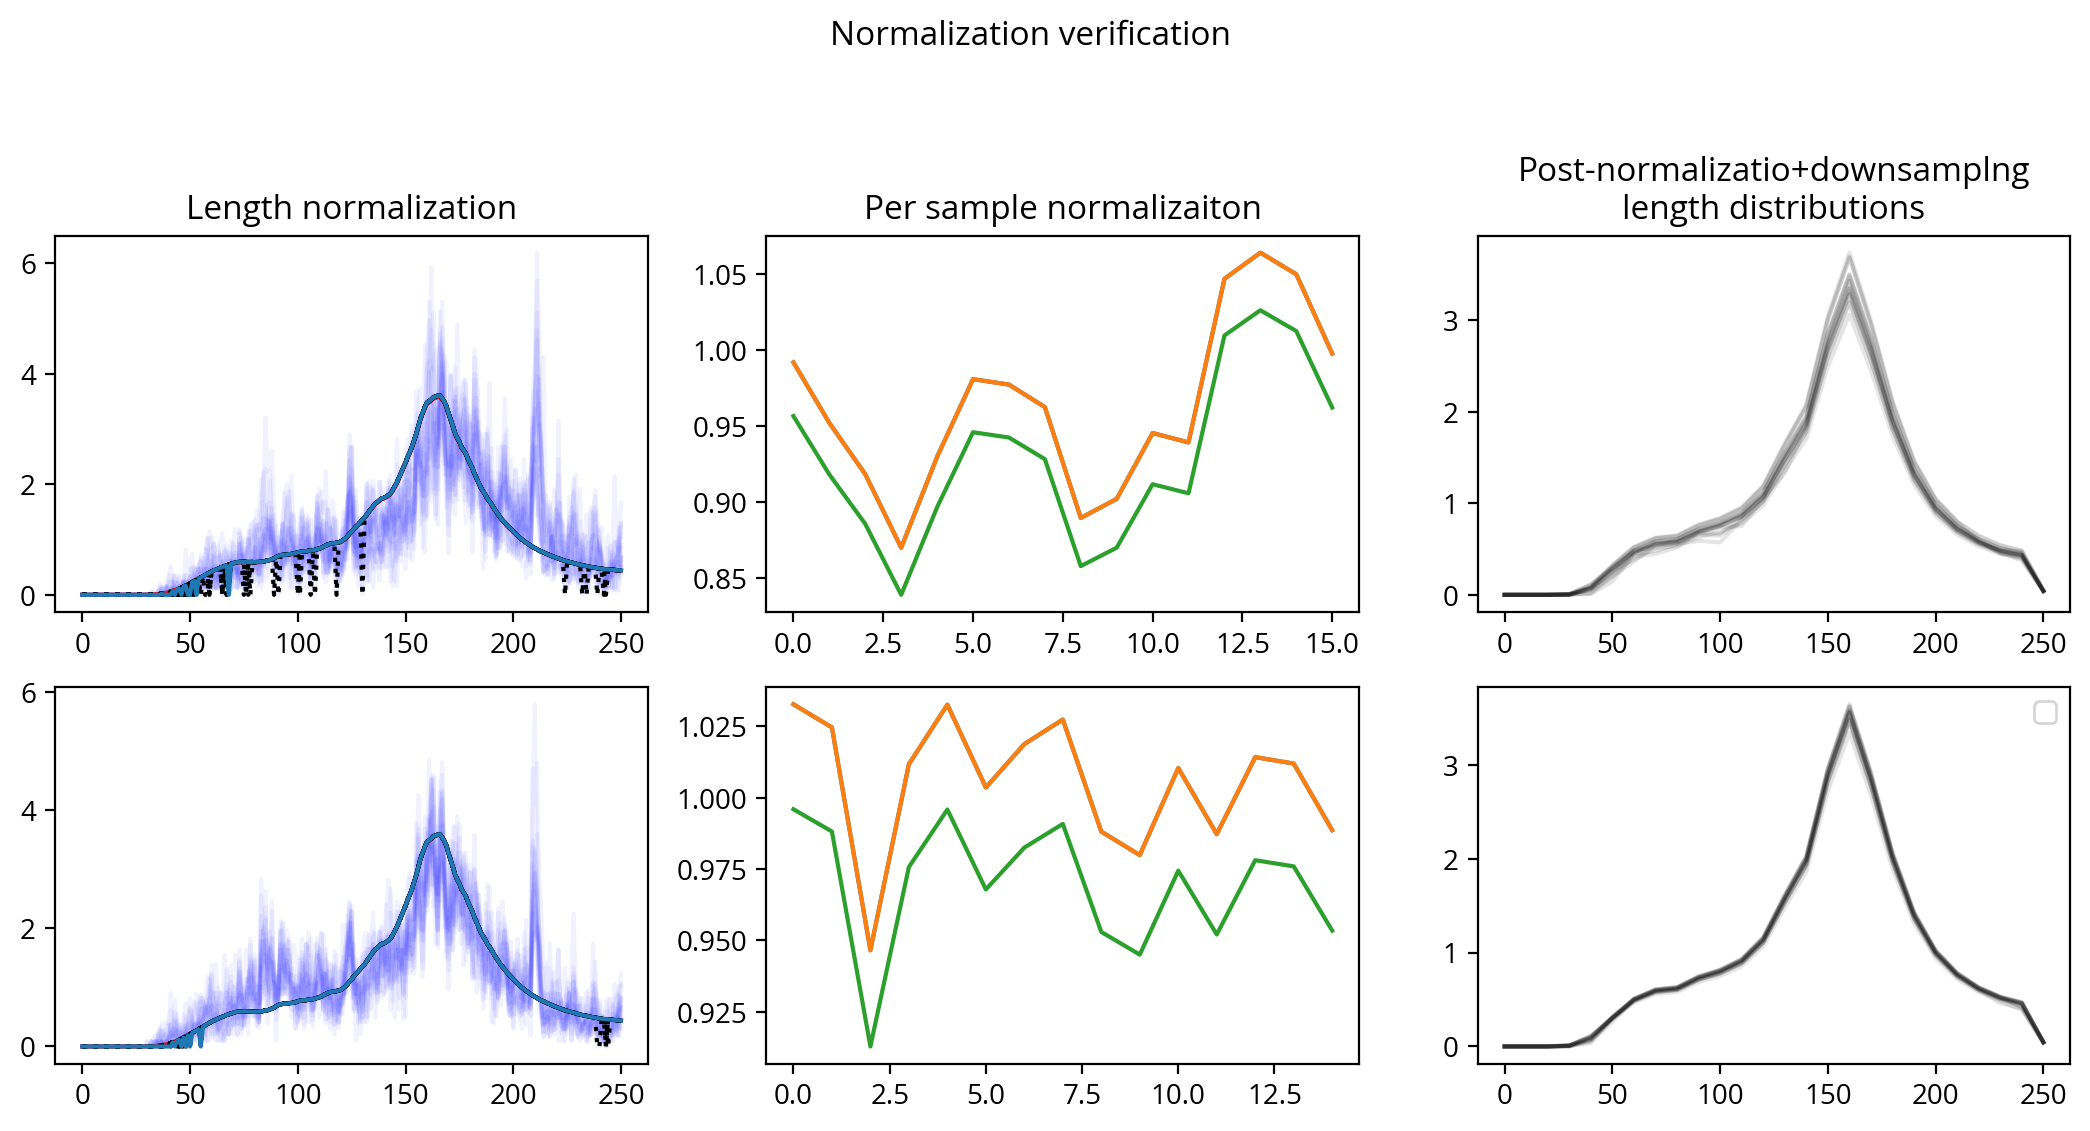

In [29]:
fig = combined_model.plot_normalization_sanity_check()

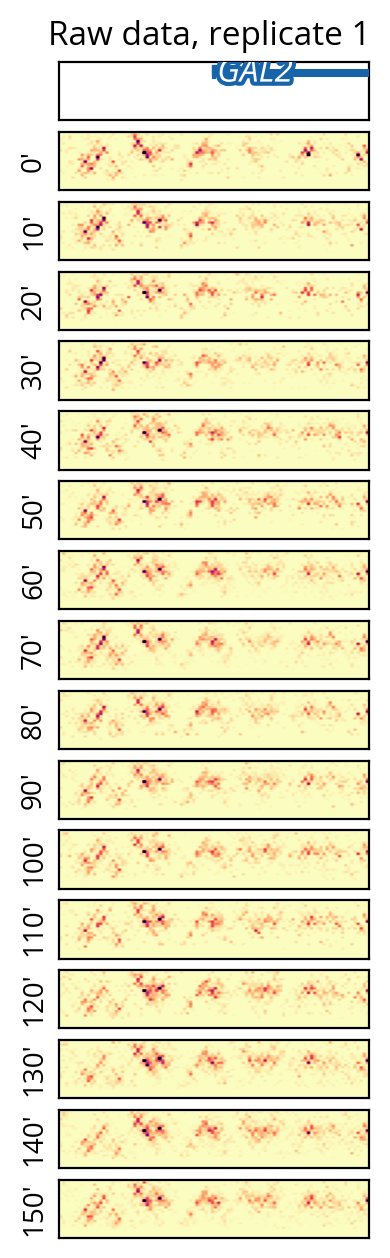

In [45]:
fig = combined_model.chrom1_model.plot_raw_data(figsize=(2, 7))

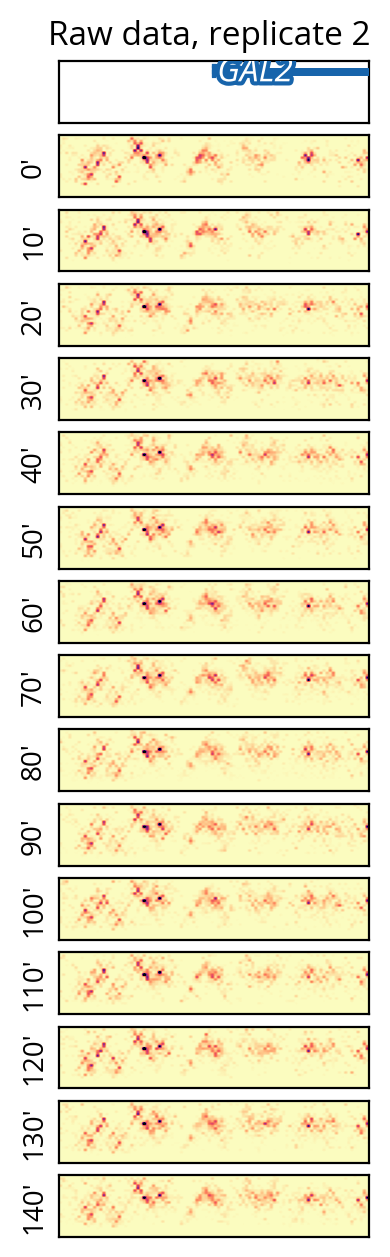

In [44]:
fig = combined_model.chrom2_model.plot_raw_data(figsize=(2, 7))

In [34]:
combined_model.setup_deconv_model()

todo: Loading copy correction N, Fr, B, testing with prototype replication data
todo: Loading prototype pipeline replication data
Trial N, need to use combined N curve


0/2600 - 00:00:00.000
500/2600 - 00:00:10.816
1000/2600 - 00:01:12.826
1500/2600 - 00:02:19.291
2000/2600 - 00:03:26.536
2500/2600 - 00:04:28.189
Completed - 00:04:33.108


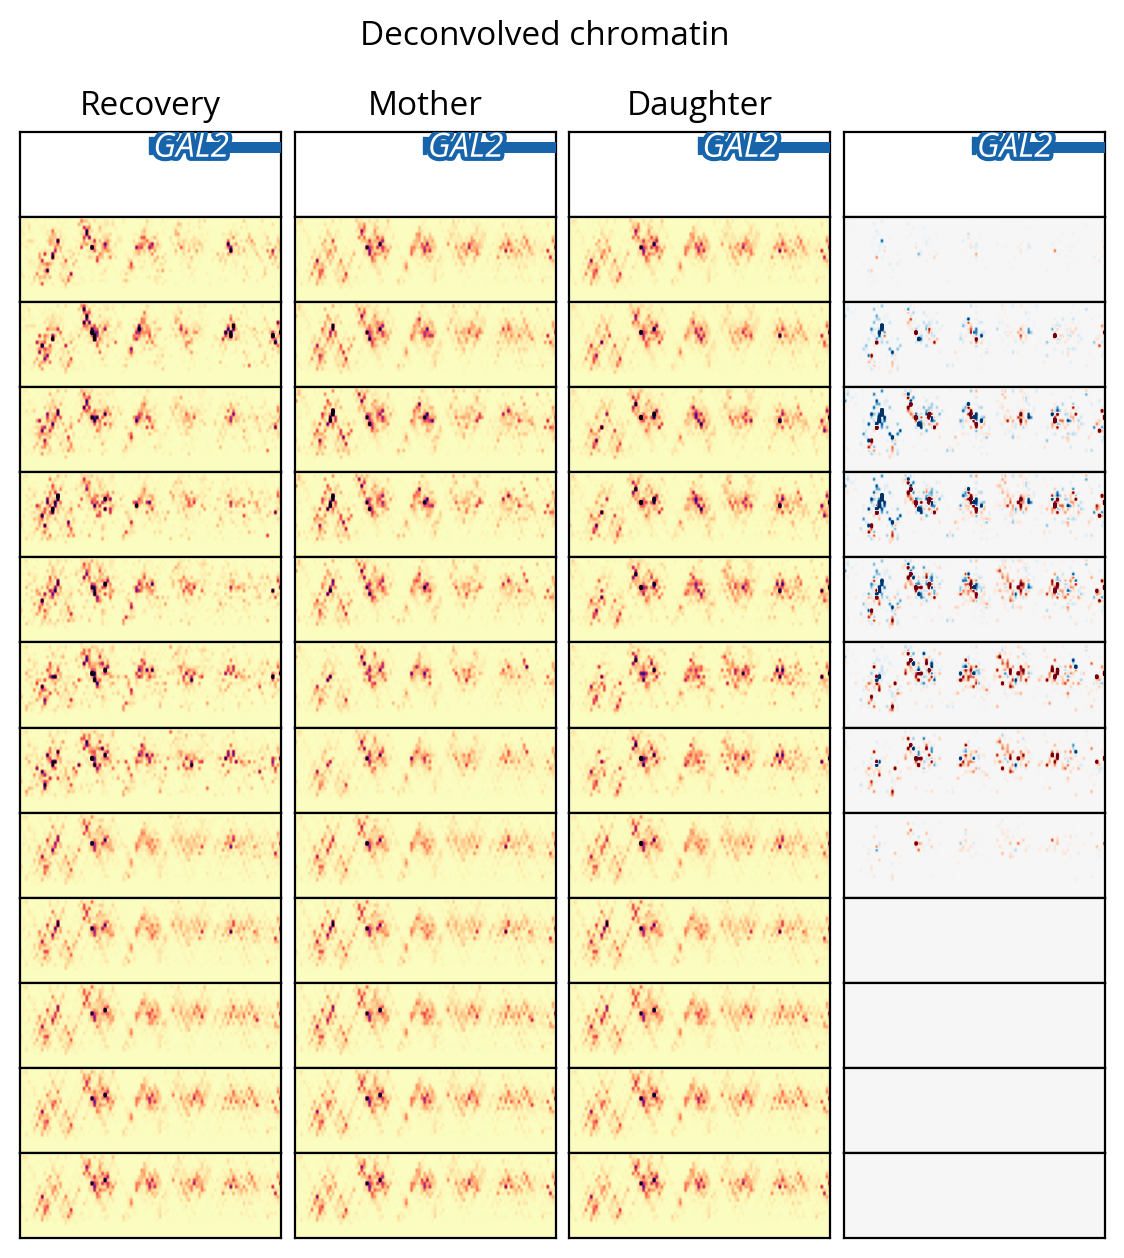

In [35]:
kappa = 0.0
combined_model.deconvolve(gamma=0.01, kappa=kappa, verbose=True)
combined_model.plot_branches(figsize=(7, 7))

0/2600 - 00:00:00.000
500/2600 - 00:00:10.925
1000/2600 - 00:01:14.110
1500/2600 - 00:02:23.521
2000/2600 - 00:03:32.885
2500/2600 - 00:04:36.326
Completed - 00:04:41.304


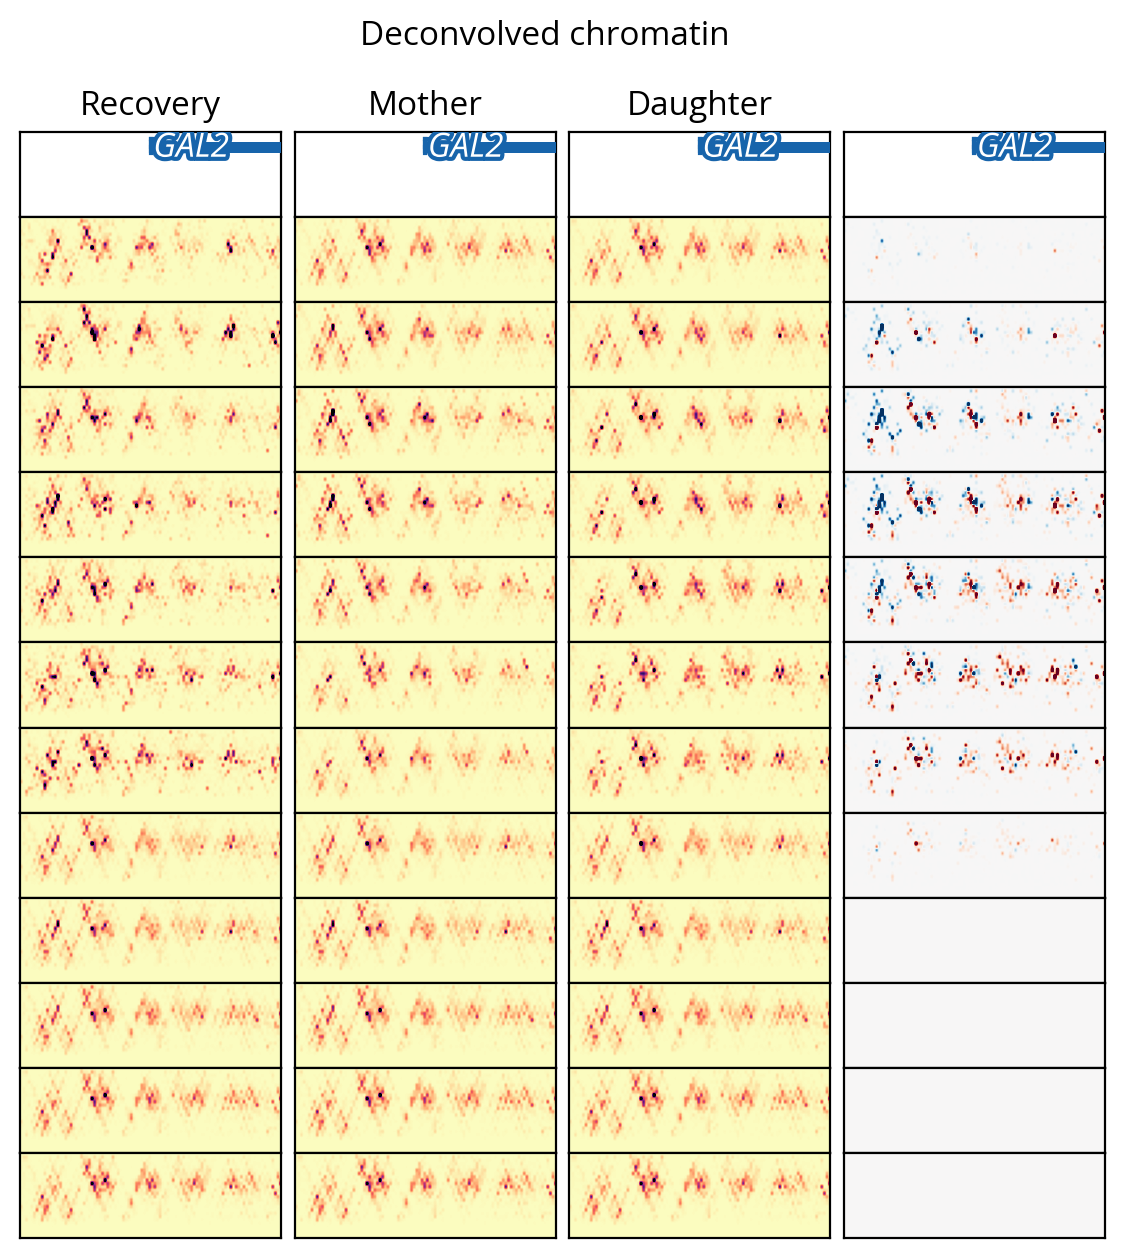

In [36]:
kappa = 0.001
combined_model.deconvolve(gamma=0.01, kappa=kappa, verbose=True)
combined_model.plot_branches(figsize=(7, 7))

0/2600 - 00:00:00.000
500/2600 - 00:00:11.173
1000/2600 - 00:01:17.227
1500/2600 - 00:02:26.766
2000/2600 - 00:03:35.371
2500/2600 - 00:04:37.740
Completed - 00:04:42.565


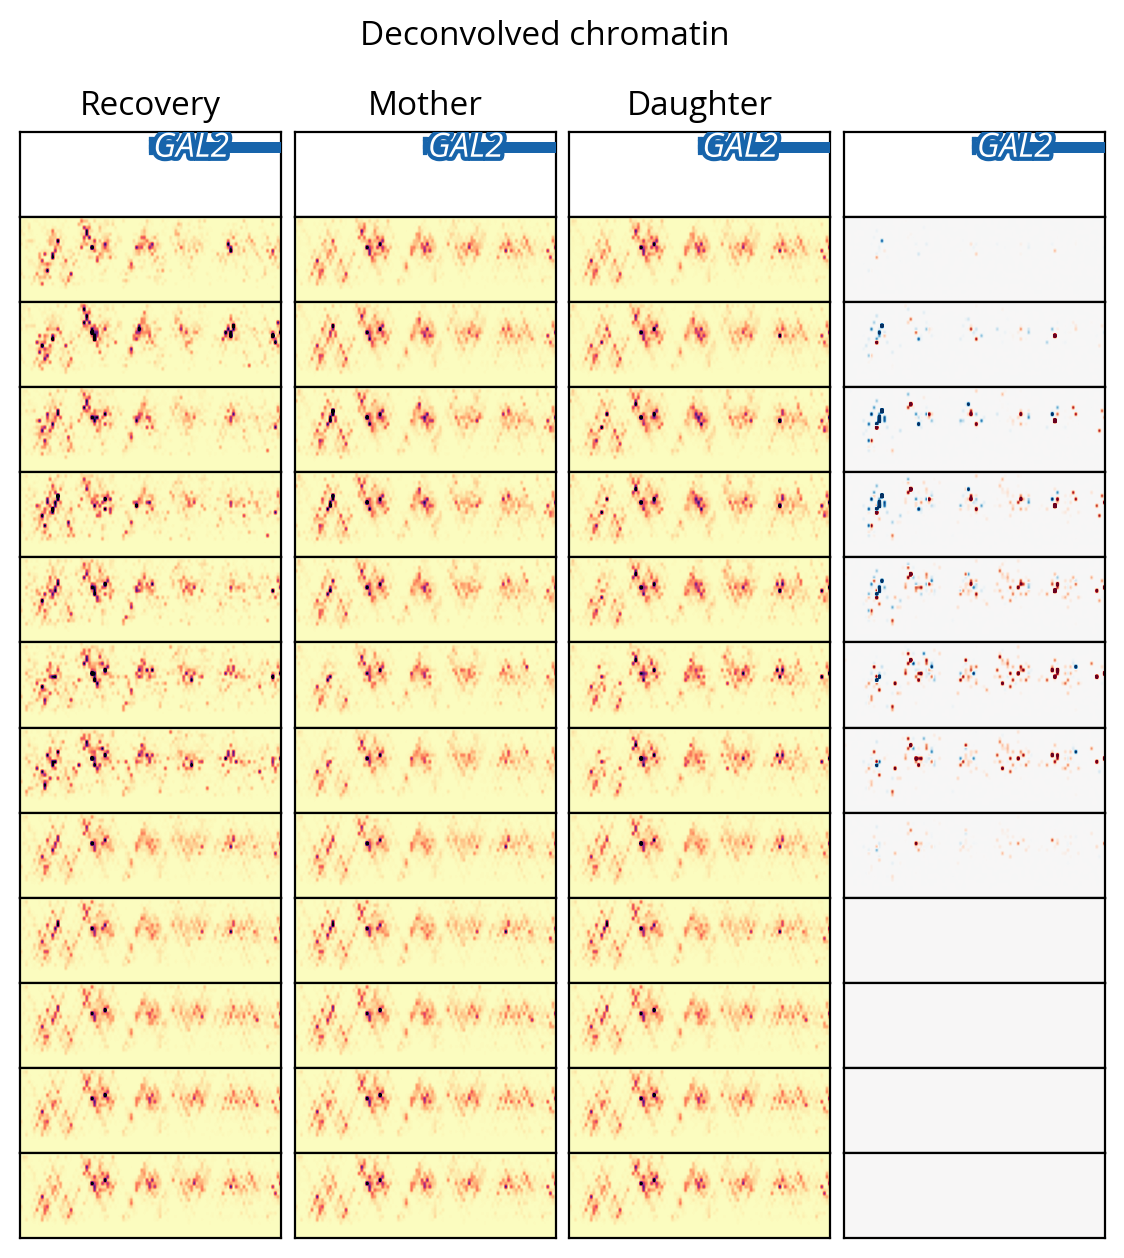

In [37]:
kappa = 0.008
combined_model.deconvolve(gamma=0.01, kappa=kappa, verbose=True)
combined_model.plot_branches(figsize=(7, 7))

0/2600 - 00:00:00.000
500/2600 - 00:00:10.798
1000/2600 - 00:01:11.974
1500/2600 - 00:02:19.333
2000/2600 - 00:03:27.676
2500/2600 - 00:04:29.353
Completed - 00:04:34.185


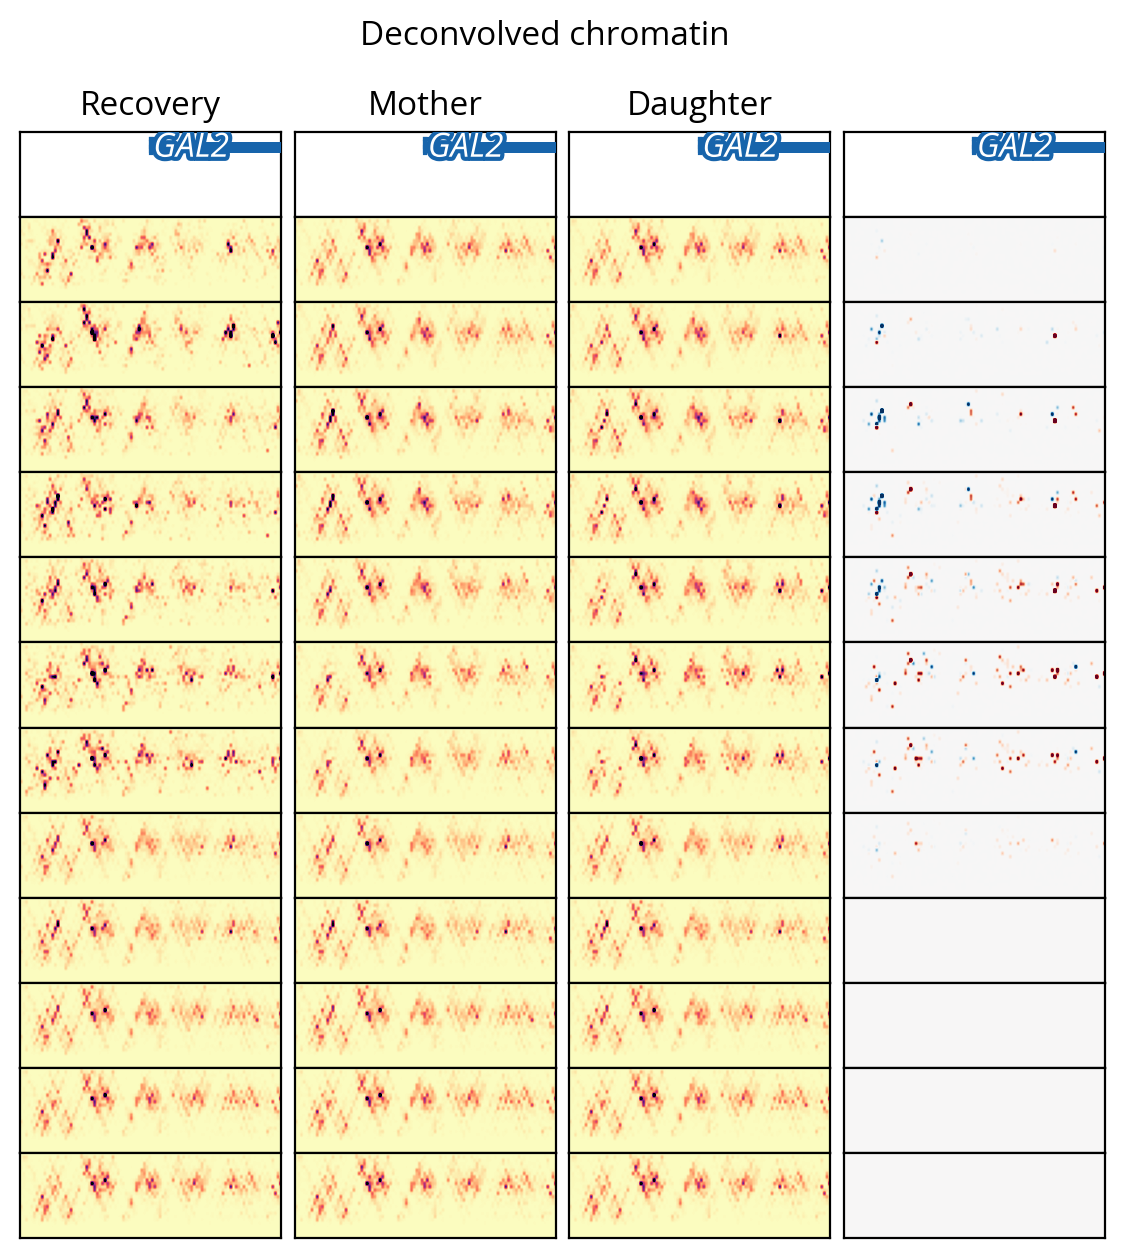

In [39]:
kappa = 0.012
combined_model.deconvolve(gamma=0.01, kappa=kappa, verbose=True)
combined_model.plot_branches(figsize=(7, 7))

0/2600 - 00:00:00.002
500/2600 - 00:00:11.120
1000/2600 - 00:01:12.930
1500/2600 - 00:02:19.443
2000/2600 - 00:03:26.812
2500/2600 - 00:04:29.082
Completed - 00:04:33.940


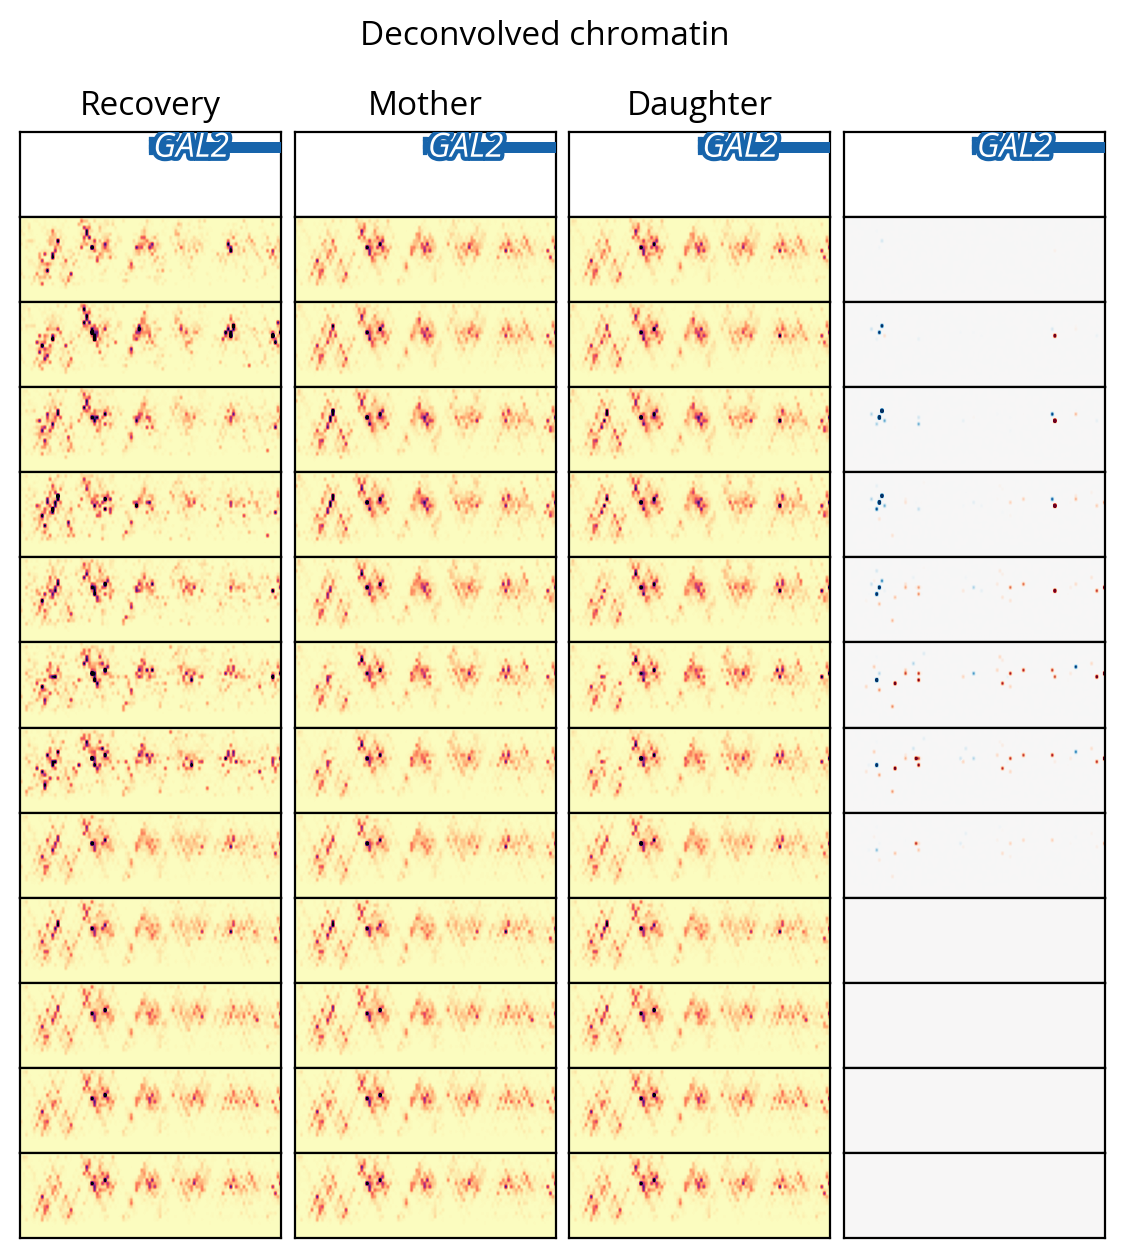

In [42]:
kappa = 0.02
combined_model.deconvolve(gamma=0.01, kappa=kappa, verbose=True)
combined_model.plot_branches(figsize=(7, 7))

0/2600 - 00:00:00.001
500/2600 - 00:00:10.871
1000/2600 - 00:01:12.018
1500/2600 - 00:02:19.001
2000/2600 - 00:03:26.049
2500/2600 - 00:04:27.605
Completed - 00:04:32.468


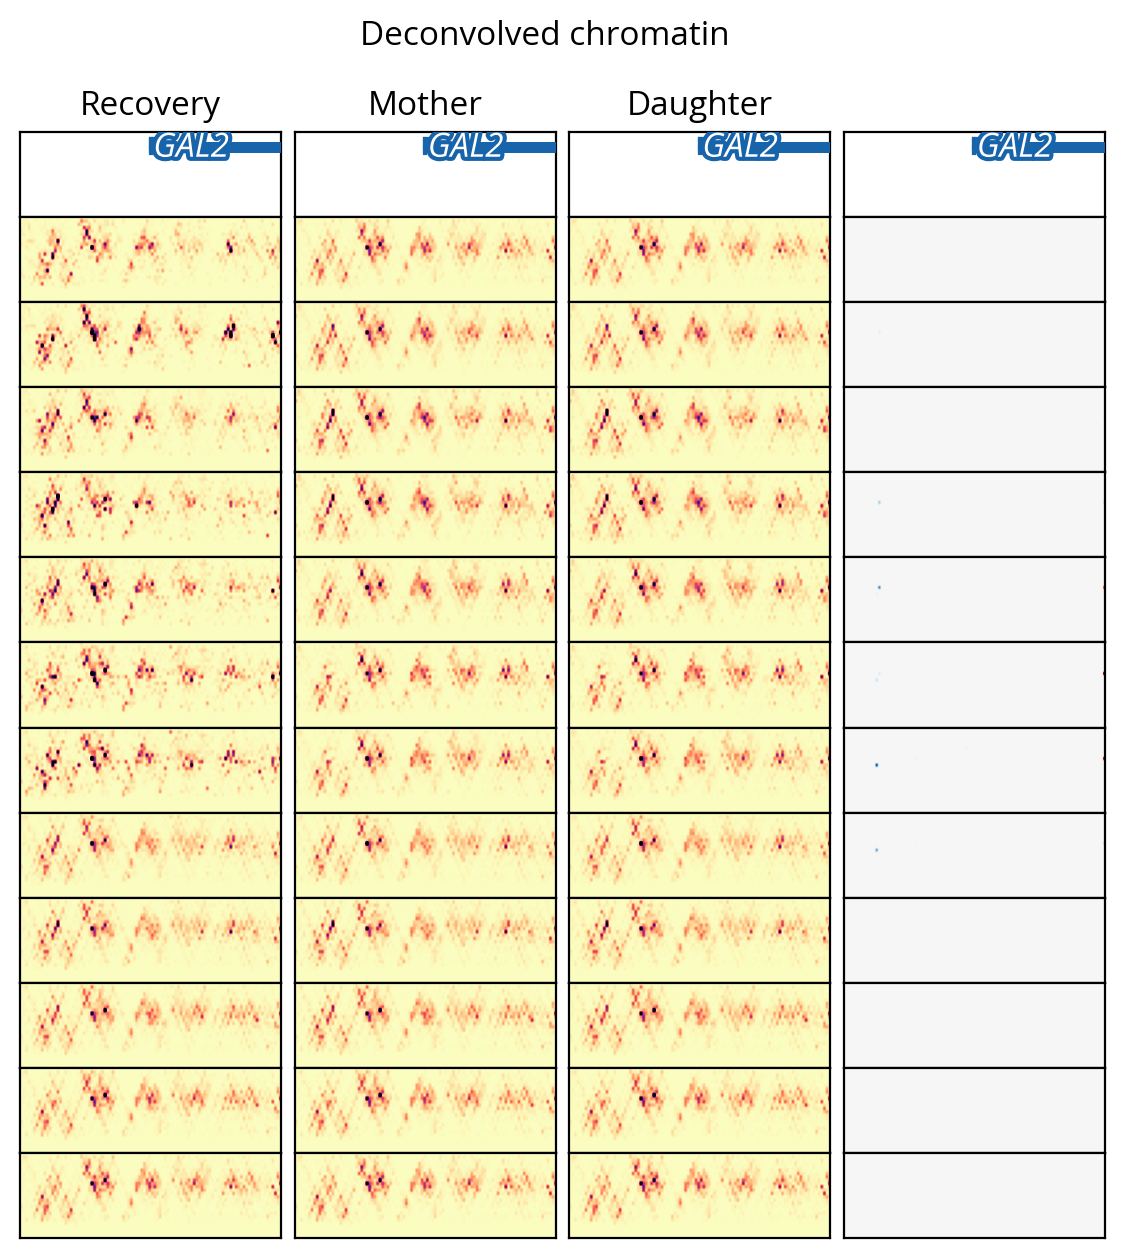

In [46]:
kappa = 0.04
combined_model.deconvolve(gamma=0.01, kappa=kappa, verbose=True)
combined_model.plot_branches(figsize=(7, 7))

In [ ]:
from pipeline.expression_analysis import ExpressionAnalysis
from src.GenomeDeconvolutionAnalysis import GenomeDeconvolutionAnalysis


output_directory = 'output/prototype_pipeline_subset/'
expression_analysis = ExpressionAnalysis(output_directory)
genome_analysis = GenomeDeconvolutionAnalysis(outdir=
    f"{output_directory}/chromatin_deconvolution/deconvolution_data")


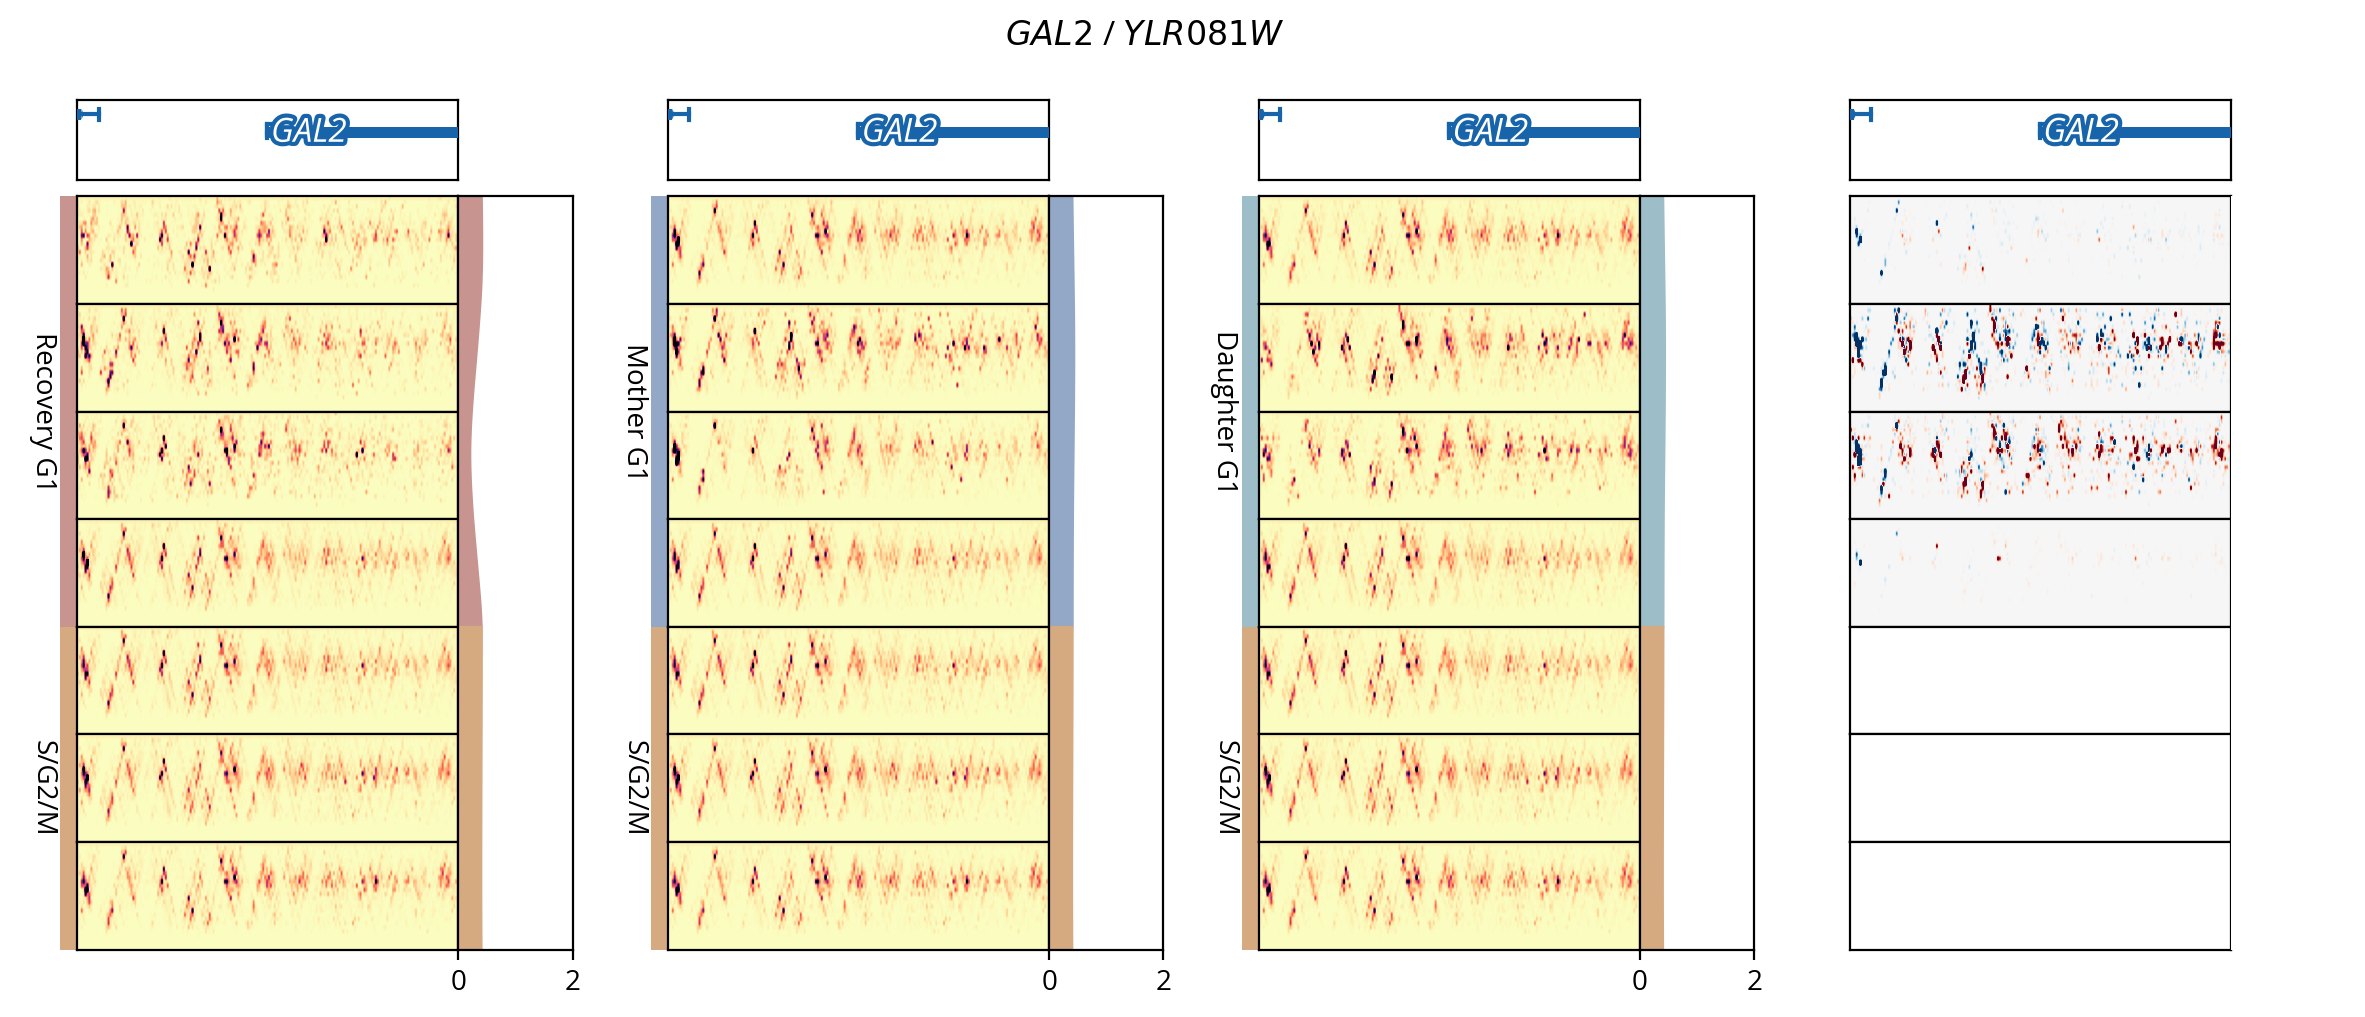

In [48]:
fig = genome_analysis.plot_gene('GAL2', config1, expression_analysis)


0/2600 - 00:00:00.000
500/2600 - 00:00:11.503
1000/2600 - 00:01:17.173
1500/2600 - 00:02:27.499
2000/2600 - 00:03:37.787
2500/2600 - 00:04:40.633
Completed - 00:04:45.606


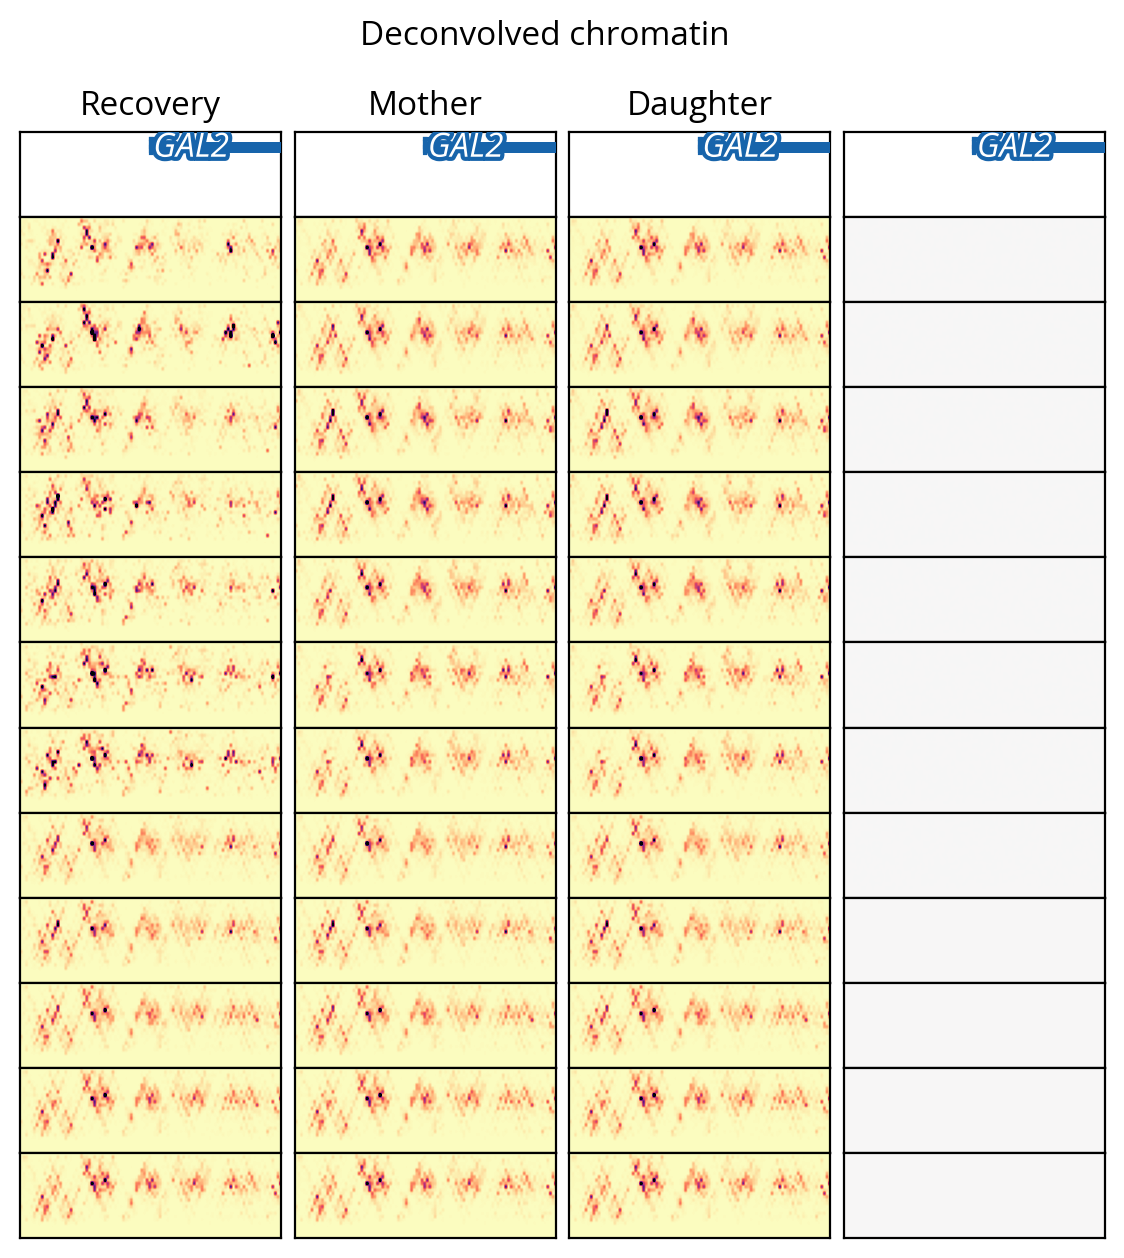

In [41]:
kappa = 1
combined_model.deconvolve(gamma=0.01, kappa=kappa, verbose=True)
combined_model.plot_branches(figsize=(7, 7))

In [654]:
from src.geneset import create_windows_to_deconvolve

window_set_2kb = create_windows_to_deconvolve(round_window=2000)
window_set_2kb.to_csv("datasets/computed_mnase/test_window_set_2kb.csv", index=False)


Defining test windows to deconvolve, rounded to the nearest 10000
Criteria for gene selection: Verified genes greater than 500 long,less than 0.5 mean expression, less than 0.1 std expression
Number of verified genes with low expression: 41
Defining test windows to deconvolve, rounded to the nearest 2000
Criteria for gene selection: Verified genes greater than 500 long,less than 0.5 mean expression, less than 0.1 std expression
Number of verified genes with low expression: 41


# Analysis of chromatin deconvolution

1. Start with sanity checks, show that we are able to load any of the deconvolution windows

In [613]:

def load_deconvolved_window(chrom, span, chromatin_deconvolution_directory):
    """Load the deconvolved F for a previously deconvolved 10kb window"""
    filepath = f'deconvolution_data/chr{chrom}/chr{chrom}_{span[0]}_{span[1]}_F.npy'
    deconv_F_path = f'{chromatin_deconvolution_directory}/{filepath}'
    F_data = np.load(deconv_F_path)
    return F_data


In [817]:
from src.config import load_default_chrom_configs

def load_combined_model_for_row(row, chromatin_deconvolution_directory):
    """"Load the deconvolution data from disk and place in combined model for
    analysis"""
    mnase_span = row.start, row.end
    chrom = row.chr

    loaded_F_data = load_deconvolved_window(chrom, mnase_span, 
        chromatin_deconvolution_directory)

    config1, config2 = load_default_chrom_configs()

    from src.combined_chromatin_model import CombinedChromatinModel
    combined_model = CombinedChromatinModel(config1=config1, config2=config2)
    combined_model.load_mnase_span(chrom, mnase_span)
    combined_model.setup_deconv_model()
    combined_model.solver.F = loaded_F_data
    
    return combined_model


In [1788]:
output_directory = \
    'output/prototype_pipeline_subset/'
chromatin_deconvolution_directory = \
    f'{output_directory}/chromatin_deconvolution_staging/'

gene_name = 'DSE3'

# Streamline of combined model loading of deconvolution data from disk
# from the trial windows
window_set_2kb = pd.read_csv('datasets/computed_mnase/test_window_set_2kb.csv')
row = window_set_2kb[window_set_2kb['name'] == gene_name] .iloc[0]
combined_model = load_combined_model_for_row(row, 
   chromatin_deconvolution_directory)


Loading chromosome reads: 15
Loading target length distribution:  datasets/computed_mnase/target_length_distribution.csv
Loading G data from combined replication run, 3/10/25
Refactor to use the output directory, of the replication deconvolution run
Normalizing to mean 1, to target length distribution, to target 10kb occupancy sums.
And downsampling from (16, 251, 9999) to (16, 26, 1000)
Loading chromosome reads: 15
Loading target length distribution:  datasets/computed_mnase/target_length_distribution.csv
Loading G data from combined replication run, 3/10/25
Refactor to use the output directory, of the replication deconvolution run
Normalizing to mean 1, to target length distribution, to target 10kb occupancy sums.
And downsampling from (15, 251, 9999) to (15, 26, 1000)
todo: Loading copy correction N, Fr, B, testing with prototype replication data
Loading single replication profile, 3/1/25
Trial N, need to use combined N curve


In [1779]:
F = combined_model.solver.F

In [1790]:
# combined_model.plot_branches(figsize=(41, 11))
# plt.savefig(f'/Users/trung/Desktop/trial_run_chromatin_deconv_10k_windows/{gene_name}_difference.png')

In [1791]:
from src.helpers import calc_entropy
from src.sgd import read_nondubious_genes_dataset

Loading target length distribution:  datasets/computed_mnase/target_length_distribution.csv


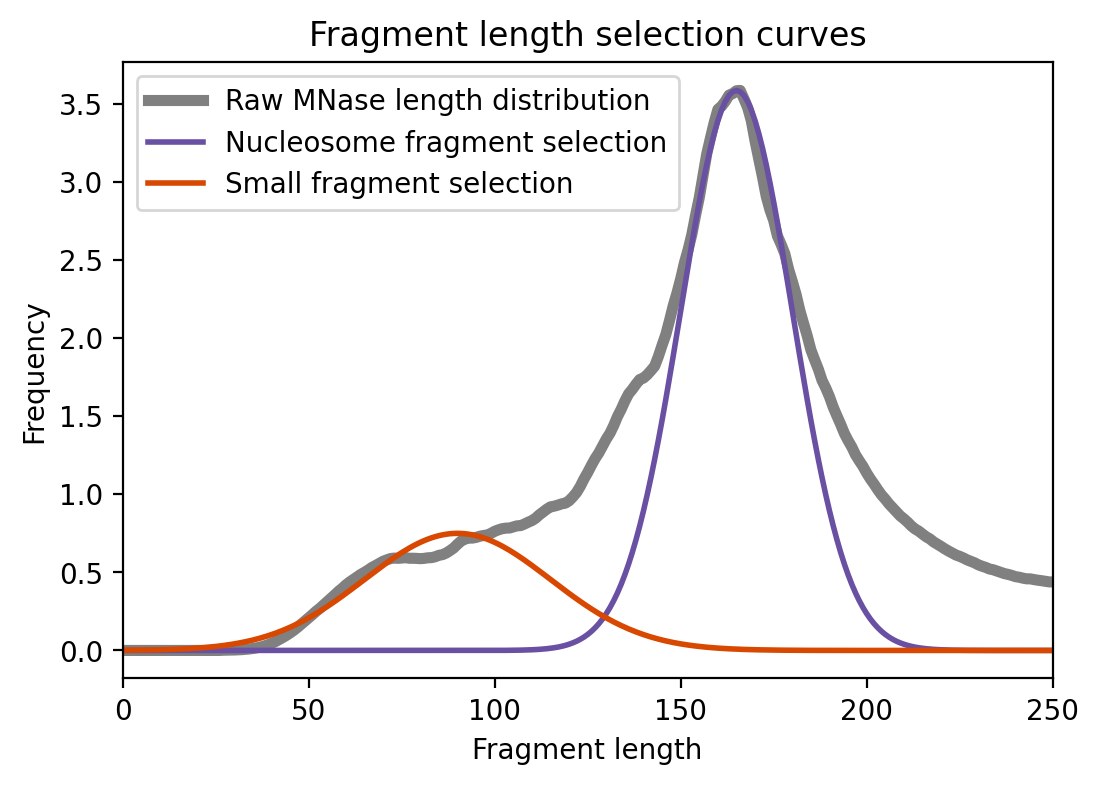

In [1792]:
from src.chromatin_metrics import retrieve_fragment_length_selection_curves, \
    downsample_kernel, select_F_imgs_in_window

nuc_curve, intermediate_curve, smal_curve = retrieve_fragment_length_selection_curves()

In [1794]:
from src.sgd import select_genes_in_window

genes = read_nondubious_genes_dataset()
genes_in_window = select_genes_in_window(genes, row.chr, (row.start, row.end))

In [1795]:
F = combined_model.solver.F
gene = genes_in_window[genes_in_window['gene'] == metrics_gene_name].iloc[0]


Loading target length distribution:  datasets/computed_mnase/target_length_distribution.csv


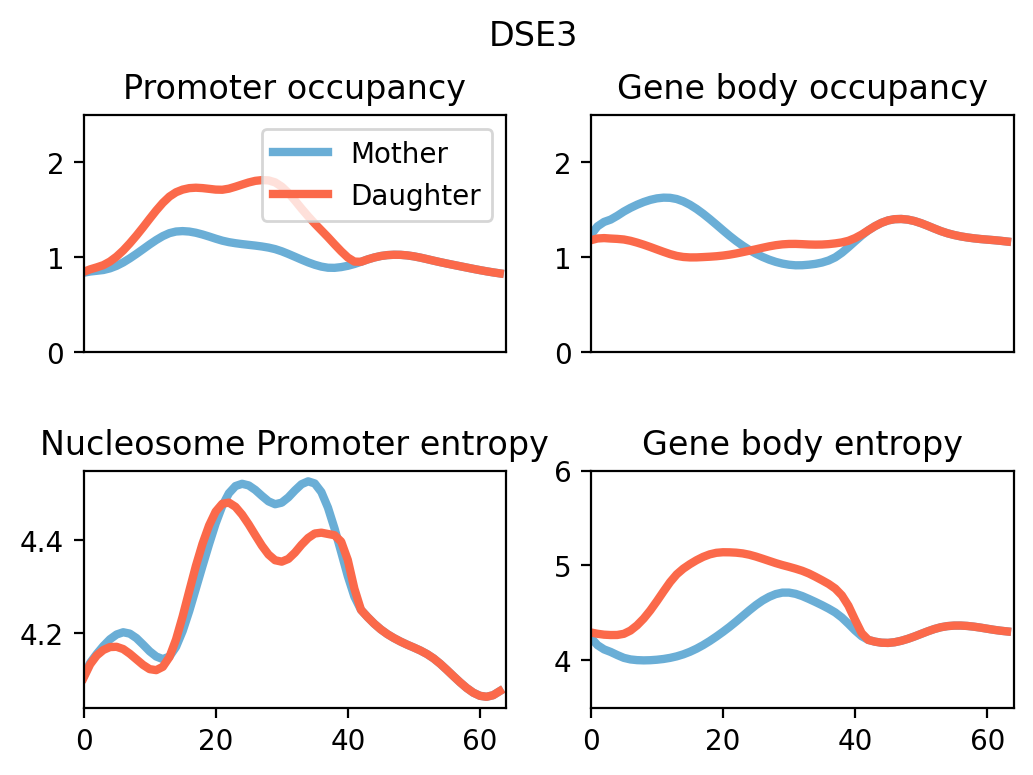

In [1803]:
from src.chromatin_metrics import compute_metrics_for_promoter_and_gene_body

compute_metrics_for_promoter_and_gene_body

prom_entropies, gb_entropies, promoter_means, gb_means = \
    compute_metrics_for_promoter_and_gene_body(config1, gene, F, 
                                               gene_name, (row.start, row.end),
                                               plot=True)


In [1808]:
cg1_mean = promoter_means[config1.cg1_indices()].mean()
dg1_mean = promoter_means[config1.dg1_indices()].mean()
cg1_mean / dg1_mean

# Next step, compute these for many genes and plot the volcano plot.


0.7347040933103837

In [ ]:
# 1. Load a gene's chromatin context from 10kb window, starting with TSS
#       (should also be translateable into origin analysis)
#       (may add option to normalize later)

# 2. Modular plan for analysis:

# 2. Compute chromatin metrics for analysis:

# 2.1. CG1/DG1 analysis

# 2.2. Gene expression analysis


In [ ]:
# Let's start a workflow in which we can load a gene, compute some of the chromatin
# metrics described above for a few genes.


# 1. load a gene including its promoter and gene body
# 2. compute its metrics: promoter occupancy, gene body entropy
# 3. stores in a dataframe for each.


In [1955]:
from src.GenomeDeconvolutionAnalysis import GenomeDeconvolutionAnalysis
chromatin_data_dir = f"{output_directory}/chromatin_deconvolution/deconvolution_data"
genome_analysis = GenomeDeconvolutionAnalysis(chromatin_data_dir)

In [1956]:
gene_metric_regions = load_p1_gene_regions()

In [2180]:
from src.reference_data import load_p1_gene_regions
from src.sgd import get_orfname

gene_name = 'DSE3'

gene_metric_regions = load_p1_gene_regions()
orfname = get_orfname(gene_name)
gene = gene_metric_regions.loc[orfname]

chrom = gene.chr
promoter_span = gene.promoter_start, gene.promoter_end
gene_body_span = gene.gene_body_start, gene.gene_body_end


In [2187]:
from src.chromatin_metrics import compute_chromatin_metric

gene_body_data_F, loaded_gene_body_span = genome_analysis.load_mnase_span(chrom, 
    gene_body_span)
promoter_data_F, loaded_promoter_span = genome_analysis.load_mnase_span(chrom, 
    promoter_span)

gene_body_nucleosome_entropy = compute_chromatin_metric(gene_body_data_F,
    fragment_type='nucleosome', metric_type='entropy')
promoter_small_occupancy = compute_chromatin_metric(promoter_data_F, 
    fragment_type='small', metric_type='occupancy')


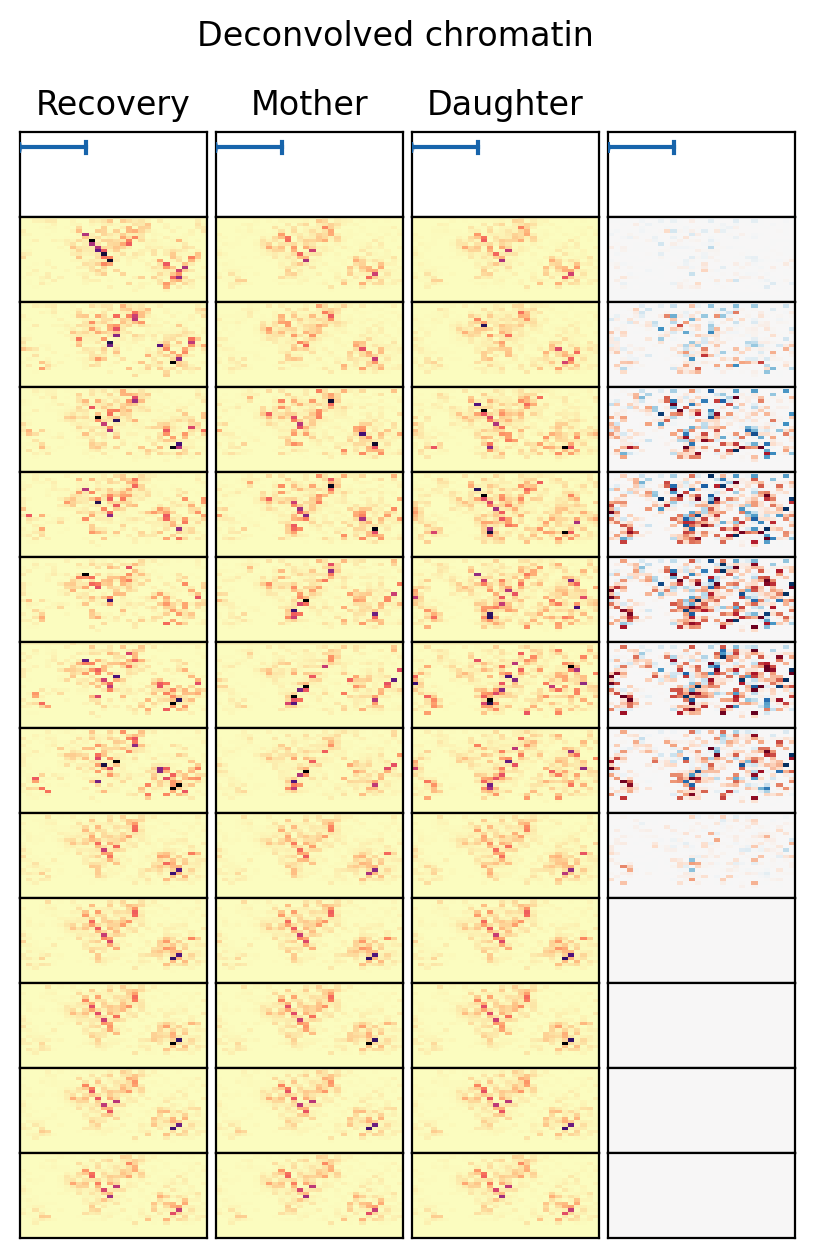

In [2190]:
fig = plot_branches(config1, chrom, promoter_span, promoter_data_F)

In [2583]:
from src.timer import Timer

timer = Timer()
n_genes = len(gene_metric_regions)
m_tps = config1.H.shape[1]

small_promoter_occupancies_df = pd.DataFrame(np.zeros((n_genes, m_tps)),
    index=gene_metric_regions.index)
nucleosome_gene_body_occupancies_df = pd.DataFrame(np.zeros((n_genes, m_tps)),
    index=gene_metric_regions.index)
small_gene_body_occupancies_df = pd.DataFrame(np.zeros((n_genes, m_tps)),
    index=gene_metric_regions.index)
nucleosome_genebody_entropies_df = pd.DataFrame(np.zeros((n_genes, m_tps)), 
    index=gene_metric_regions.index)

i = 0
skip_genes = []
for orfname, gene in gene_metric_regions.iterrows():

    promoter_span = gene.promoter_start, gene.promoter_end
    gene_body_span = gene.gene_body_start, gene.gene_body_end

    chrom = gene.chr

    try:
        gene_body_data_F, loaded_gene_body_span = genome_analysis.load_mnase_span(chrom, 
        gene_body_span)
        promoter_data_F, loaded_promoter_span = genome_analysis.load_mnase_span(chrom, 
        promoter_span)

        gene_body_nucleosome_entropy = compute_chromatin_metric(gene_body_data_F,
            fragment_type='nucleosome', metric_type='entropy')
        promoter_small_occupancy = compute_chromatin_metric(promoter_data_F, 
            fragment_type='small', metric_type='occupancy')
        
        # Occupancy measures in the gene body to help figure out proper controls
        # for regulatory dynamics in the promoter
        gene_body_small_occupancy = compute_chromatin_metric(gene_body_data_F,
            fragment_type='small', metric_type='occupancy')
        gene_body_nucleosome_occupancy = compute_chromatin_metric(gene_body_data_F, 
            fragment_type='nucleosome', metric_type='occupancy')

        # Store entropy for the nucleosomes in the gene body
        # Store the occupancy values, promoter (small) and gene body (small, nuc)
        small_promoter_occupancies_df.loc[orfname] = promoter_small_occupancy
        nucleosome_genebody_entropies_df.loc[orfname] = gene_body_nucleosome_entropy
        nucleosome_gene_body_occupancies_df.loc[orfname] = gene_body_nucleosome_occupancy
        small_gene_body_occupancies_df.loc[orfname] = gene_body_small_occupancy

    except ValueError:
        # Skip missing window
        skip_genes.append(orfname)
        pass
    
    if i % 100 == 0:
        timer.print_time(f"{i}/{n_genes}")
        
    i += 1

print(f"Skipped {len(skip_genes)} genes.")


0/5578 - 00:00:00.339
100/5578 - 00:00:26.929
200/5578 - 00:00:53.444
300/5578 - 00:01:19.937
400/5578 - 00:01:46.409
500/5578 - 00:02:12.946
600/5578 - 00:02:39.477
700/5578 - 00:03:05.931
800/5578 - 00:03:32.536
900/5578 - 00:03:58.994
1000/5578 - 00:04:25.450
1100/5578 - 00:04:51.964
1200/5578 - 00:05:18.461
1300/5578 - 00:05:44.958
1400/5578 - 00:06:11.329
1500/5578 - 00:06:37.770
1600/5578 - 00:07:04.299
1700/5578 - 00:07:30.759
1800/5578 - 00:07:57.215
1900/5578 - 00:08:23.809
2000/5578 - 00:08:50.341
2100/5578 - 00:09:16.745
2200/5578 - 00:09:43.123
2300/5578 - 00:10:09.490
2400/5578 - 00:10:35.644
2500/5578 - 00:11:01.994
2600/5578 - 00:11:28.415
2700/5578 - 00:11:54.752
2800/5578 - 00:12:21.082
2900/5578 - 00:12:47.416
3000/5578 - 00:13:13.763
3100/5578 - 00:13:40.236
3200/5578 - 00:14:06.557
3300/5578 - 00:14:32.924
3400/5578 - 00:14:59.347
3500/5578 - 00:15:25.706
3600/5578 - 00:15:52.044
3700/5578 - 00:16:18.403
3800/5578 - 00:16:44.760
3900/5578 - 00:17:11.163
4000/5578 - 

In [2650]:
from src.utils import mkdirs_safe

chromatin_analysis_directory = \
    f'{output_directory}/chromatin_analysis/'
mkdirs_safe([chromatin_analysis_directory])

small_promoter_occupancies_df.to_csv(f"{chromatin_analysis_directory}/small_prom_occupancies.csv")
nucleosome_genebody_entropies_df.to_csv(f"{chromatin_analysis_directory}/nuc_gb_entropies.csv")
nucleosome_gene_body_occupancies_df.to_csv(f"{chromatin_analysis_directory}/nuc_gb_occupancies.csv")
small_gene_body_occupancies_df.to_csv(f"{chromatin_analysis_directory}/small_gb_occupancies.csv")

Creating directory: output/prototype_pipeline_subset//chromatin_analysis/...
